# 🚗 CADP Accident Detection — Redesigned Pipeline
**Project:** Harnessing Deep Learning to Optimize Emergency Response  
**Model:** EfficientNet-B0 (torchvision) — Binary Classification  
**Dataset:** CADP — 230 YouTube traffic videos, 22.3 hours total  

---

## What changed from v1 and why

| Issue in v1 | Fix in v2 |
|---|---|
| Negatives = 3s BEFORE crash (wrong label) | Negatives = genuine normal traffic from full videos |
| YOLOv8n vehicle filter — 18–42s per clip | Removed — not needed with correct negative source |
| Frame 105 heuristic fails on short clips | Skips clips < 105 frames, confirmed 90.7% have accident frames |
| YOLOv11-cls — single-frame, no temporal | EfficientNet-B0 — better ImageNet transfer, richer metrics |
| Top-1 accuracy only | Precision, Recall, F1, AUC-ROC tracked per epoch |

## Pipeline
1. **Setup** — install, mount Drive, configure paths  
2. **Dataset Build** — extract positives from `extracted_frames/`, negatives from `forth_investigation/` using annotation timestamps  
3. **Training** — EfficientNet-B0 with cosine LR, early stopping, Drive checkpoints  
4. **Evaluation** — confusion matrix, AUC-ROC, sample predictions  
5. **Inference** — frame-by-frame timeline on new video  
6. **Export** — ONNX for deployment  

> ⚠️ **GPU Required:** Runtime → Change runtime type → T4 GPU

In [1]:
# ============================================================
# 1.1  Install dependencies (run ONCE, then restart runtime)
# ============================================================
!pip install -q torchmetrics

print("✅ Dependencies installed.")
print("⚠️  If first run: Runtime > Restart session, then skip to 1.2")

✅ Dependencies installed.
⚠️  If first run: Runtime > Restart session, then skip to 1.2


In [5]:
# ============================================================
# 1.2  Mount Drive + all imports + all paths
# ============================================================

# ── Drive ──────────────────────────────────────────────────
from google.colab import drive
import os
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("✅ Drive already mounted")

# ── Imports ────────────────────────────────────────────────
import json, shutil, random, time
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchmetrics import Accuracy, Precision, Recall, F1Score, AUROC
from torchmetrics import ConfusionMatrix

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

# ── Reproducibility ────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Source data paths ──────────────────────────────────────
CADP_ROOT       = Path('/content/drive/MyDrive/Car_accident_detection')
CADP_DATASET    = CADP_ROOT / 'Dataset'
FRAMES_DIR      = CADP_DATASET / 'manual' / 'extracted_frames'
VIDEOS_DIR      = CADP_DATASET / 'forth_investigation'
ANNO_FILE       = CADP_DATASET / 'manual' / 'annotations_1531762138.1303267.json'

# ── Working directory (persistent on Drive) ────────────────
WORK_DIR        = Path('/content/drive/MyDrive/Colab Notebooks/grad-project/program-memory')
CACHE_DIR       = WORK_DIR / 'cache'
CHECKPOINT_DIR  = WORK_DIR / 'checkpoints'
RUNS_DIR        = WORK_DIR / 'runs'
DATASET_DIR     = WORK_DIR / 'cls_dataset_v2'   # v2 — new pipeline

for d in [CACHE_DIR, CHECKPOINT_DIR, RUNS_DIR, DATASET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Device ─────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"🖥️  GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("❌ No GPU — Go to Runtime > Change runtime type > T4 GPU")

# ── Sanity checks ──────────────────────────────────────────
for label, path in [("extracted_frames", FRAMES_DIR),
                    ("forth_investigation", VIDEOS_DIR),
                    ("annotations json",   ANNO_FILE)]:
    exists = path.exists()
    print(f"  {'✅' if exists else '❌'}  {label}: {path}")

✅ Drive already mounted
🖥️  GPU: Tesla T4 (15.6 GB)
  ✅  extracted_frames: /content/drive/MyDrive/Car_accident_detection/Dataset/manual/extracted_frames
  ✅  forth_investigation: /content/drive/MyDrive/Car_accident_detection/Dataset/forth_investigation
  ✅  annotations json: /content/drive/MyDrive/Car_accident_detection/Dataset/manual/annotations_1531762138.1303267.json


In [6]:
# ============================================================
# 2.1  Load annotation JSON + build accident-window index
# ============================================================
# The JSON maps video filename → list of annotation segments.
# Each segment has keyframes with 'frame' values in SECONDS.
# We use this to know which time windows contain accidents so
# we can EXCLUDE them when sampling normal-traffic negatives.
# ============================================================

with open(ANNO_FILE, 'r') as f:
    raw_anno = json.load(f)

def get_accident_windows(video_id: str) -> list:
    """Return [(start_sec, end_sec), ...] for one video."""
    windows = []
    for ann in raw_anno.get(video_id, []):
        kfs = ann.get('keyframes', [])
        if len(kfs) >= 2:
            t_start = kfs[0]['frame']
            t_end   = kfs[-1]['frame']
            if t_end > t_start:
                windows.append((t_start, t_end))
    return windows

def window_is_safe(t_start, t_end, acc_windows, buffer=1.0):
    """True if [t_start, t_end] does NOT overlap any accident window
    (with a safety buffer on each side to avoid ambiguous frames)."""
    for ws, we in acc_windows:
        if t_start < (we + buffer) and t_end > (ws - buffer):
            return False
    return True

# Quick stats
total_videos  = len(raw_anno)
videos_no_ann = sum(1 for v in raw_anno.values() if not v)
total_windows = sum(len(get_accident_windows(v)) for v in raw_anno)
print(f"✅ Annotation file loaded")
print(f"   Videos annotated : {total_videos}")
print(f"   Videos with 0 ann: {videos_no_ann}")
print(f"   Total acc windows: {total_windows}")
print(f"   Avg windows/video: {total_windows/(total_videos-videos_no_ann):.1f}")

✅ Annotation file loaded
   Videos annotated : 226
   Videos with 0 ann: 9
   Total acc windows: 1416
   Avg windows/video: 6.5


In [4]:
# ============================================================
# 3.1  Build Classification Dataset  (RESUMABLE)
# ============================================================
#
# POSITIVES  — extracted_frames/{clip}/
#   • Skip clips with < ACCIDENT_START frames (9.3% of clips)
#   • From remaining frames >= ACCIDENT_START, sample evenly
#     up to MAX_ACC_PER_CLIP frames per clip
#   • Frames named: 0.jpg, 1.jpg, 2.jpg ...
#
# NEGATIVES  — forth_investigation/{video}.mp4
#   • Slide a 2-second window over full video duration
#   • Exclude any window that overlaps an accident annotation
#     (+ 1-second safety buffer each side)
#   • From safe windows, sample up to MAX_NORM_PER_VIDEO
#   • Extract the middle frame of each safe window via OpenCV
#
# Both sources are on Google Drive → local copy to /tmp
# before frame reads to eliminate per-frame Drive latency.
# ============================================================

import math

ACCIDENT_START    = 105       # frame index where accident begins
FPS               = 30.0      # confirmed 30fps for all clips
WINDOW_SEC        = 2.0       # length of each normal-traffic window
BUFFER_SEC        = 1.0       # exclusion buffer around accident zones
MAX_ACC_PER_CLIP  = 5         # max accident frames sampled per clip
MAX_NORM_PER_VID  = 30        # max normal frames sampled per video
TRAIN_RATIO       = 0.70
VAL_RATIO         = 0.20

PROGRESS_FILE  = CACHE_DIR / 'build_progress_v2.json'
CACHE_DONE     = CACHE_DIR / 'dataset_v2_complete.json'
LOCAL_TMP      = Path('/content/tmp_work')

# ── helpers ────────────────────────────────────────────────
def load_progress():
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE) as f:
            return json.load(f)
    return {
        'done_clips': [],
        'done_videos': [],
        'counts': {'train':{'acc':0,'norm':0},
                   'val':  {'acc':0,'norm':0},
                   'test': {'acc':0,'norm':0}},
        'skipped': {'short_clip':0, 'corrupt':0, 'no_safe_window':0}
    }

def save_progress(p):
    with open(PROGRESS_FILE, 'w') as f:
        json.dump(p, f)

def dataset_done():
    return CACHE_DONE.exists()

def safe_imread(path):
    """Read image, return None on any failure."""
    try:
        img = cv2.imread(str(path))
        return img if (img is not None and img.size > 0) else None
    except Exception:
        return None

def sample_evenly(items, n):
    """Sample up to n items evenly spread across the list."""
    if len(items) <= n:
        return items
    step = len(items) / n
    return [items[int(i * step)] for i in range(n)]

# ── early exit ─────────────────────────────────────────────
if dataset_done():
    with open(CACHE_DONE) as f:
        done_info = json.load(f)
    print("⚡ Dataset already built! Skipping.\n")
    for split in ['train', 'val', 'test']:
        for label in ['accident', 'no_accident']:
            n = len(list((DATASET_DIR/split/label).glob('*.jpg')))
            print(f"   {split}/{label}: {n:,} frames")

else:
    # ── create output folders ───────────────────────────────
    for split in ['train', 'val', 'test']:
        for label in ['accident', 'no_accident']:
            (DATASET_DIR / split / label).mkdir(parents=True, exist_ok=True)

    progress = load_progress()
    done_clips  = set(progress['done_clips'])
    done_videos = set(progress['done_videos'])
    counts      = progress['counts']
    skipped     = progress['skipped']

    # ── deterministic split assignment ─────────────────────
    all_clips  = sorted([d for d in FRAMES_DIR.iterdir() if d.is_dir()])
    all_videos = sorted([v for v in VIDEOS_DIR.glob('*.mp4')])

    random.Random(SEED).shuffle(all_clips)
    random.Random(SEED).shuffle(all_videos)

    n_train = int(len(all_clips) * TRAIN_RATIO)
    n_val   = int(len(all_clips) * VAL_RATIO)
    clip_split = {}
    for i, c in enumerate(all_clips):
        clip_split[c.name] = ('train' if i < n_train
                              else 'val' if i < n_train + n_val
                              else 'test')

    n_train_v = int(len(all_videos) * TRAIN_RATIO)
    n_val_v   = int(len(all_videos) * VAL_RATIO)
    vid_split = {}
    for i, v in enumerate(all_videos):
        vid_split[v.name] = ('train' if i < n_train_v
                             else 'val' if i < n_train_v + n_val_v
                             else 'test')

    remaining_clips  = [c for c in all_clips  if c.name not in done_clips]
    remaining_videos = [v for v in all_videos if v.name not in done_videos]

    total_work = len(remaining_clips) + len(remaining_videos)
    print(f"🔄 Resuming: {len(done_clips)} clips done, "
          f"{len(done_videos)} videos done")
    print(f"   Remaining: {len(remaining_clips)} clips + "
          f"{len(remaining_videos)} videos\n")

    # ══════════════════════════════════════════════════════
    # PHASE 1 — POSITIVES from extracted_frames
    # ══════════════════════════════════════════════════════
    print("── Phase 1: extracting POSITIVE frames ──")
    for clip_dir in tqdm(remaining_clips, desc="Accident clips"):
        frames_all = sorted(clip_dir.glob('*.jpg'),
                            key=lambda p: int(p.stem))
        total_frames = len(frames_all)

        if total_frames < ACCIDENT_START:
            skipped['short_clip'] += 1
            progress['done_clips'].append(clip_dir.name)
            save_progress(progress)
            continue

        # frames in accident zone
        acc_frames = [f for f in frames_all
                      if int(f.stem) >= ACCIDENT_START]

        chosen = sample_evenly(acc_frames, MAX_ACC_PER_CLIP)
        split  = clip_split[clip_dir.name]

        # copy clip to local tmp (eliminates per-frame Drive reads)
        if LOCAL_TMP.exists(): shutil.rmtree(LOCAL_TMP)
        LOCAL_TMP.mkdir(parents=True)
        for src in chosen:
            shutil.copy2(src, LOCAL_TMP / src.name)

        saved_count = 0
        for src_name in [f.name for f in chosen]:
            local_path = LOCAL_TMP / src_name
            img = safe_imread(local_path)
            if img is None:
                skipped['corrupt'] += 1
                continue
            dst = (DATASET_DIR / split / 'accident'
                   / f"{clip_dir.name}_f{src_name.replace('.jpg',''):>06}.jpg")
            shutil.copy2(str(local_path), str(dst))
            counts[split]['acc'] += 1
            saved_count += 1

        progress['done_clips'].append(clip_dir.name)
        progress['counts']  = counts
        progress['skipped'] = skipped
        save_progress(progress)

    if LOCAL_TMP.exists(): shutil.rmtree(LOCAL_TMP)

    # ══════════════════════════════════════════════════════
    # PHASE 2 — NEGATIVES from forth_investigation
    # ══════════════════════════════════════════════════════
    print("\n── Phase 2: extracting NEGATIVE frames ──")
    for video_path in tqdm(remaining_videos, desc="Normal videos"):
        vid_name   = video_path.name
        acc_windows = get_accident_windows(vid_name)

        cap  = cv2.VideoCapture(str(video_path))
        fps  = cap.get(cv2.CAP_PROP_FPS) or FPS
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        total_dur = total_frames / fps

        # generate all 2-second safe windows
        safe_windows = []
        t = 0.0
        while t + WINDOW_SEC <= total_dur:
            if window_is_safe(t, t + WINDOW_SEC, acc_windows, BUFFER_SEC):
                safe_windows.append(t)
            t += WINDOW_SEC

        if not safe_windows:
            skipped['no_safe_window'] += 1
            cap.release()
            progress['done_videos'].append(vid_name)
            save_progress(progress)
            continue

        chosen_starts = sample_evenly(safe_windows, MAX_NORM_PER_VID)
        split = vid_split[vid_name]

        for idx, t_start in enumerate(chosen_starts):
            t_mid      = t_start + WINDOW_SEC / 2.0
            frame_idx  = int(t_mid * fps)
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret or frame is None or frame.size == 0:
                skipped['corrupt'] += 1
                continue
            vid_stem = vid_name.replace('.mp4', '').replace('-','_')
            dst = (DATASET_DIR / split / 'no_accident'
                   / f"{vid_stem}_{idx:04d}.jpg")
            cv2.imwrite(str(dst), frame)
            counts[split]['norm'] += 1

        cap.release()
        progress['done_videos'].append(vid_name)
        progress['counts']  = counts
        progress['skipped'] = skipped
        save_progress(progress)

    # ── finalize ───────────────────────────────────────────
    with open(CACHE_DONE, 'w') as f:
        json.dump({'counts': counts, 'skipped': skipped}, f, indent=2)
    PROGRESS_FILE.unlink(missing_ok=True)

    print("\n✅ Dataset complete!\n")
    for split in ['train', 'val', 'test']:
        a = counts[split]['acc']
        n = counts[split]['norm']
        print(f"   {split:5s}: {a+n:,} images  "
              f"(accident={a:,}, normal={n:,})")
    print(f"\n   Skipped — short clips:    {skipped['short_clip']}")
    print(f"   Skipped — corrupt frames: {skipped['corrupt']}")
    print(f"   Skipped — no safe window: {skipped['no_safe_window']}")

NameError: name 'CACHE_DIR' is not defined

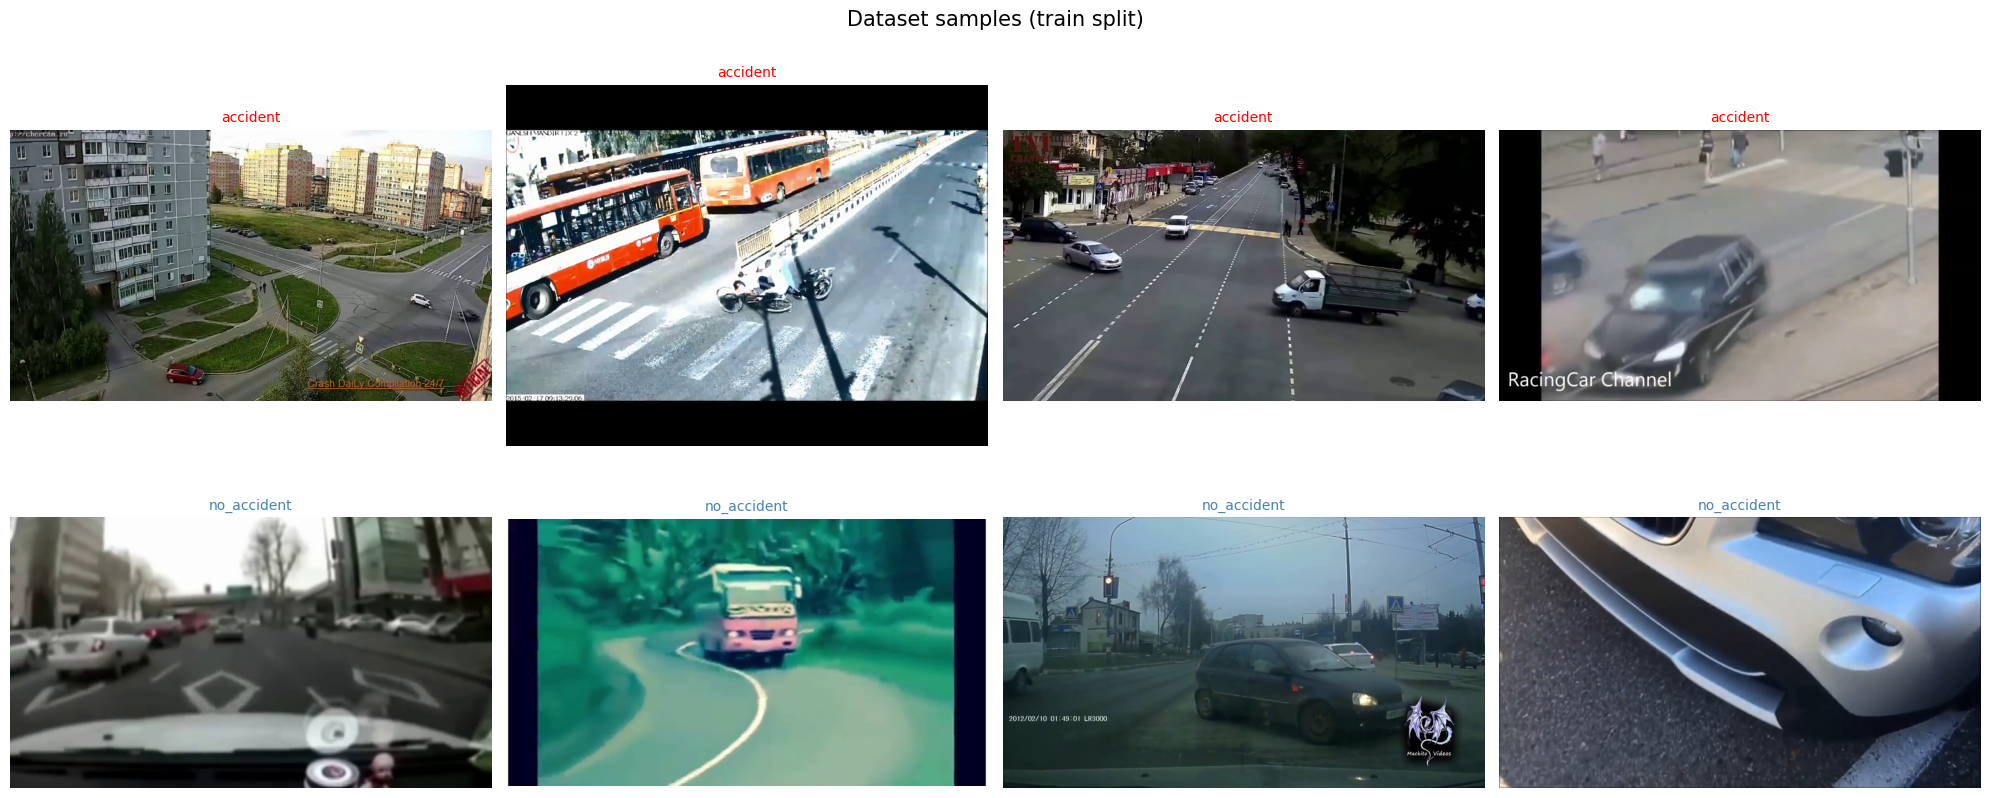


📊 Class balance:
   train: 7,065 total | accident 59% | normal 41%
   val  : 2,131 total | accident 57% | normal 43%
   test : 1,117 total | accident 57% | normal 43%


In [7]:
# ============================================================
# 3.2  Visualize dataset samples + class balance
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Dataset samples (train split)', fontsize=15)

for row, label in enumerate(['accident', 'no_accident']):
    samples = list((DATASET_DIR / 'train' / label).glob('*.jpg'))
    if not samples:
        print(f"⚠️  No {label} samples found yet — run cell 3.1 first")
        continue
    chosen = random.sample(samples, min(4, len(samples)))
    for col, p in enumerate(chosen):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        color = 'red' if label == 'accident' else 'steelblue'
        axes[row][col].set_title(label, color=color, fontsize=10)
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Class balance:")
for split in ['train', 'val', 'test']:
    acc  = len(list((DATASET_DIR/split/'accident').glob('*.jpg')))
    norm = len(list((DATASET_DIR/split/'no_accident').glob('*.jpg')))
    tot  = acc + norm
    if tot:
        print(f"   {split:5s}: {tot:,} total | "
              f"accident {acc/tot*100:.0f}% | normal {norm/tot*100:.0f}%")

In [9]:
# ============================================================
# 4.1  PyTorch Dataset + Transforms
# ============================================================

class AccidentDataset(Dataset):
    def __init__(self, root: Path, split: str, transform=None):
        self.items     = []
        self.transform = transform
        self.class_to_idx = {'accident': 1, 'no_accident': 0}
        for label, idx in self.class_to_idx.items():
            folder = root / split / label
            if folder.exists():
                for p in folder.glob('*.jpg'):
                    self.items.append((p, idx))
        random.Random(SEED).shuffle(self.items)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ImageNet normalization stats
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

eval_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

train_ds = AccidentDataset(DATASET_DIR, 'train', train_transform)
val_ds   = AccidentDataset(DATASET_DIR, 'val',   eval_transform)
test_ds  = AccidentDataset(DATASET_DIR, 'test',  eval_transform)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,
                      num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"✅ Datasets ready")
print(f"   Train : {len(train_ds):,} samples  ({len(train_dl)} batches)")
print(f"   Val   : {len(val_ds):,}  samples  ({len(val_dl)} batches)")
print(f"   Test  : {len(test_ds):,}  samples  ({len(test_dl)} batches)")

✅ Datasets ready
   Train : 7,065 samples  (221 batches)
   Val   : 2,131  samples  (67 batches)
   Test  : 1,117  samples  (35 batches)


In [10]:
# ============================================================
# 4.2  EfficientNet-B0 — partial freeze + stronger regularization
# ============================================================
# Changes from v1:
#   • Freeze first 5 of 8 feature blocks  →  trainable params
#     drop from 4.0M to ~1.2M  →  fixes overfitting
#   • Dropout 0.3 → 0.5                   →  more regularization
#   • weight_decay 1e-4 → 1e-3            →  more regularization
# ============================================================

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

# ── Partial freeze: lock first 5 feature blocks ────────────
# EfficientNet-B0 has features[0..8]:
#   0 = stem conv
#   1..8 = MBConv blocks (8 blocks total)
# We freeze blocks 0-5, fine-tune blocks 6-8 + classifier head
FREEZE_UP_TO = 6   # freeze features[0] through features[5]

for i, block in enumerate(model.features):
    if i < FREEZE_UP_TO:
        for param in block.parameters():
            param.requires_grad = False

# ── Replace classifier head ────────────────────────────────
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),   # was 0.3
    nn.Linear(in_features, 2)
)
model = model.to(DEVICE)

# ── Class weights ──────────────────────────────────────────
n_acc  = len(list((DATASET_DIR/'train'/'accident').glob('*.jpg')))
n_norm = len(list((DATASET_DIR/'train'/'no_accident').glob('*.jpg')))
n_total = n_acc + n_norm
w_acc  = n_total / (2 * n_acc)  if n_acc  > 0 else 1.0
w_norm = n_total / (2 * n_norm) if n_norm > 0 else 1.0
class_weights = torch.tensor([w_norm, w_acc], dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-3      # was 1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - train_params

print(f"✅ EfficientNet-B0 (partial freeze) ready")
print(f"   Total params     : {total_params/1e6:.1f}M")
print(f"   Frozen params    : {frozen_params/1e6:.1f}M  (features[0-5])")
print(f"   Trainable params : {train_params/1e6:.2f}M  (features[6-8] + head)")
print(f"   Dropout          : 0.5")
print(f"   Weight decay     : 1e-3")
print(f"   Class weights    : accident={w_acc:.3f}, normal={w_norm:.3f}")
print(f"   Device           : {DEVICE}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 180MB/s]


✅ EfficientNet-B0 (partial freeze) ready
   Total params     : 4.0M
   Frozen params    : 0.9M  (features[0-5])
   Trainable params : 3.16M  (features[6-8] + head)
   Dropout          : 0.5
   Weight decay     : 1e-3
   Class weights    : accident=0.845, normal=1.225
   Device           : cuda


In [ ]:
# ============================================================
# 5.1  Training — v2 (partial freeze, stronger regularization)
# ============================================================
# Saves to efficientnet_b0_v2_best.pt — v1 model is preserved.
# ============================================================

NUM_EPOCHS = 60
PATIENCE   = 15    # slightly more patience

BEST_PT   = CHECKPOINT_DIR / 'efficientnet_b0_v2_best.pt'
LAST_PT   = CHECKPOINT_DIR / 'efficientnet_b0_v2_last.pt'
HISTORY_F = CACHE_DIR       / 'train_history_v2.json'

def make_metrics():
    return {
        'acc'  : Accuracy(task='binary').to(DEVICE),
        'prec' : Precision(task='binary').to(DEVICE),
        'rec'  : Recall(task='binary').to(DEVICE),
        'f1'   : F1Score(task='binary').to(DEVICE),
        'auc'  : AUROC(task='binary').to(DEVICE),
    }

def compute_metrics(m):
    return {k: v.compute().item() for k, v in m.items()}

def run_epoch(loader, train=True):
    model.train(train)
    metrics    = make_metrics()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train: optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)
            metrics['acc'].update(preds, labels)
            metrics['prec'].update(preds, labels)
            metrics['rec'].update(preds, labels)
            metrics['f1'].update(preds, labels)
            metrics['auc'].update(probs, labels)
    return total_loss / len(loader), compute_metrics(metrics)

# ── Resume support ─────────────────────────────────────────
start_epoch = 0
best_val_f1 = 0.0
no_improve  = 0
history     = {'train': [], 'val': []}

if LAST_PT.exists():
    ckpt = torch.load(LAST_PT, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt['epoch'] + 1
    best_val_f1 = ckpt.get('best_val_f1', 0.0)
    no_improve  = ckpt.get('no_improve', 0)
    if HISTORY_F.exists():
        with open(HISTORY_F) as f:
            history = json.load(f)
    print(f"🔄 Resumed from epoch {start_epoch}  (best F1={best_val_f1:.4f})")
else:
    print("🚀 Starting fresh training (v2 — partial freeze)")

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = time.time()
    train_loss, train_m = run_epoch(train_dl, train=True)
    val_loss,   val_m   = run_epoch(val_dl,   train=False)
    scheduler.step()

    history['train'].append({'loss': train_loss, **train_m})
    history['val'].append(  {'loss': val_loss,   **val_m})
    with open(HISTORY_F, 'w') as f:
        json.dump(history, f)

    elapsed = time.time() - t0
    print(f"Ep {epoch+1:3d}/{NUM_EPOCHS} | "
          f"loss {train_loss:.4f}/{val_loss:.4f} | "
          f"F1 {train_m['f1']:.3f}/{val_m['f1']:.3f} | "
          f"AUC {val_m['auc']:.3f} | "
          f"Prec {val_m['prec']:.3f} Rec {val_m['rec']:.3f} | "
          f"{elapsed:.0f}s")

    ckpt = {'epoch': epoch, 'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_val_f1': best_val_f1, 'no_improve': no_improve}
    torch.save(ckpt, LAST_PT)

    if val_m['f1'] > best_val_f1:
        best_val_f1 = val_m['f1']
        no_improve  = 0
        torch.save(model.state_dict(), BEST_PT)
        print(f"   💾 New best F1={best_val_f1:.4f} — saved to {BEST_PT.name}")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\n⏹️  Early stopping ({PATIENCE} epochs no improvement)")
            break

print(f"\n✅ Training complete. Best val F1 = {best_val_f1:.4f}")
print(f"   v1 best: {CHECKPOINT_DIR}/efficientnet_b0_best.pt")
print(f"   v2 best: {BEST_PT}")


In [ ]:
# ============================================================
# 5.2  Training curves
# ============================================================
if not HISTORY_F.exists():
    print("No training history found — run training first.")
else:
    with open(HISTORY_F) as f:
        history = json.load(f)

    epochs = range(1, len(history['train']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training History', fontsize=15)

    metrics_to_plot = ['loss', 'f1', 'auc', 'acc', 'prec', 'rec']
    titles = ['Loss', 'F1 Score', 'AUC-ROC',
              'Accuracy', 'Precision', 'Recall']

    for ax, key, title in zip(axes.flatten(), metrics_to_plot, titles):
        tr = [e[key] for e in history['train']]
        vl = [e[key] for e in history['val']]
        ax.plot(epochs, tr, label='train', color='steelblue')
        ax.plot(epochs, vl, label='val',   color='coral')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 6.1  Full evaluation on test set
# ============================================================

# Load best weights
if BEST_PT.exists():
    model.load_state_dict(torch.load(BEST_PT, map_location=DEVICE))
    print(f"✅ Loaded best weights: {BEST_PT.name}")
else:
    print("⚠️  best.pt not found — using current model weights")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_dl, desc="Evaluating"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_probs  = torch.cat(all_probs)

# Compute metrics
test_metrics = {}
for name, metric in [
    ('Accuracy',  Accuracy(task='binary')),
    ('Precision', Precision(task='binary')),
    ('Recall',    Recall(task='binary')),
    ('F1',        F1Score(task='binary')),
    ('AUC-ROC',   AUROC(task='binary')),
]:
    if name == 'AUC-ROC':
        test_metrics[name] = metric(all_probs, all_labels).item()
    else:
        test_metrics[name] = metric(all_preds, all_labels).item()

print("\n" + "="*50)
print("📊 TEST SET RESULTS")
print("="*50)
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")
print("="*50)

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())
disp = ConfusionMatrixDisplay(cm, display_labels=['normal', 'accident'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_labels.numpy(), all_probs.numpy())
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='coral', lw=2,
        label=f"AUC = {test_metrics['AUC-ROC']:.3f}")
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 6.2  Sample predictions on test images
# ============================================================
model.eval()
samples_acc  = list((DATASET_DIR/'test'/'accident').glob('*.jpg'))
samples_norm = list((DATASET_DIR/'test'/'no_accident').glob('*.jpg'))
samples = (random.sample(samples_acc,  min(4, len(samples_acc))) +
           random.sample(samples_norm, min(4, len(samples_norm))))
random.shuffle(samples)

cols = 4
rows = math.ceil(len(samples) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.array(axes).flatten()
fig.suptitle('Test set predictions', fontsize=14)

for ax, p in zip(axes, samples):
    gt = 1 if p.parent.name == 'accident' else 0
    img_bgr = cv2.imread(str(p))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    t = eval_transform(img_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.softmax(model(t), dim=1)[0, 1].item()
    pred = 1 if prob >= 0.5 else 0
    correct = pred == gt

    ax.imshow(img_rgb)
    color  = 'green' if correct else 'red'
    symbol = '✅' if correct else '❌'
    gt_name   = 'accident' if gt   == 1 else 'normal'
    pred_name = 'accident' if pred == 1 else 'normal'
    ax.set_title(f"{symbol} GT:{gt_name}\nPred:{pred_name} ({prob:.0%})",
                 color=color, fontsize=9)
    ax.axis('off')

for ax in axes[len(samples):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

✅ Loaded: efficientnet_b0_v2_best.pt

🎬 -GpvLzopst8.mp4: 1830 frames @ 30.0fps


Inferring:   0%|          | 0/1830 [00:00<?, ?it/s]


   Raw detections  : 30/122 frames
   Smoothed alerts : 25/122 frames
   First alert at  : 15.0s
   Peak confidence : 91% at 23.5s


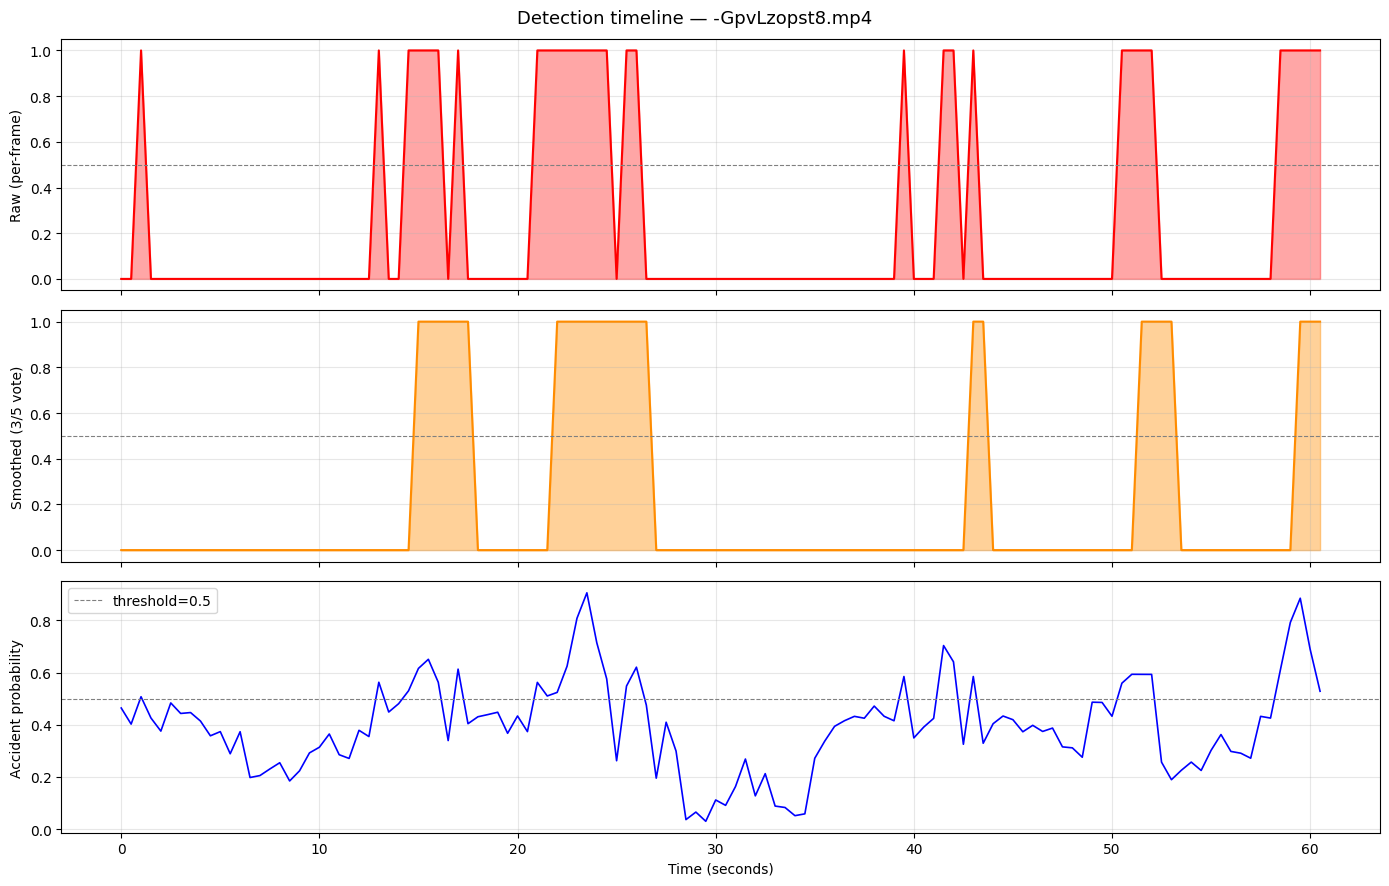

In [11]:
# ============================================================
# 7.1  Inference with temporal smoothing
# ============================================================
# Added: 5-frame sliding window majority vote.
# A detection fires only when >= VOTE_THRESHOLD of the last
# VOTE_WINDOW frames say "accident" — eliminates single spikes.
# ============================================================

VOTE_WINDOW    = 5
VOTE_THRESHOLD = 3
CONF_THRESHOLD = 0.5

def infer_video(model, video_path, sample_every_n=15, max_sec=120):
    video_path = Path(video_path)
    if not video_path.exists():
        print(f"❌ Not found: {video_path}")
        return [], []

    cap        = cv2.VideoCapture(str(video_path))
    fps        = cap.get(cv2.CAP_PROP_FPS) or 30
    total      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    max_frames = min(total, int(max_sec * fps))

    print(f"🎬 {video_path.name}: {total} frames @ {fps:.1f}fps")
    model.eval()

    raw_timeline  = []
    smooth_alerts = []
    recent_preds  = []

    for i in tqdm(range(max_frames), desc="Inferring", leave=False):
        ret, frame = cap.read()
        if not ret: break
        if i % sample_every_n != 0: continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        t = eval_transform(frame_rgb).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            prob = torch.softmax(model(t), dim=1)[0, 1].item()

        raw_pred = 1 if prob >= CONF_THRESHOLD else 0
        raw_timeline.append({'frame': i, 'time_sec': i/fps,
                              'prob': prob, 'raw': raw_pred})

        recent_preds.append(raw_pred)
        if len(recent_preds) > VOTE_WINDOW:
            recent_preds.pop(0)
        smooth = 1 if sum(recent_preds) >= VOTE_THRESHOLD else 0
        smooth_alerts.append({'frame': i, 'time_sec': i/fps,
                               'prob': prob, 'smooth': smooth})

    cap.release()

    raw_acc    = [t for t in raw_timeline  if t['raw']    == 1]
    smooth_acc = [t for t in smooth_alerts if t['smooth'] == 1]

    print(f"\n   Raw detections  : {len(raw_acc)}/{len(raw_timeline)} frames")
    print(f"   Smoothed alerts : {len(smooth_acc)}/{len(smooth_alerts)} frames")

    if smooth_acc:
        first = smooth_acc[0]
        peak  = max(raw_timeline, key=lambda x: x['prob'])
        print(f"   First alert at  : {first['time_sec']:.1f}s")
        print(f"   Peak confidence : {peak['prob']:.0%} at {peak['time_sec']:.1f}s")
    else:
        print("   No sustained accident detected")

    return raw_timeline, smooth_alerts

def plot_timeline(raw_tl, smooth_tl, video_name=""):
    times_r  = [t['time_sec'] for t in raw_tl]
    probs    = [t['prob']     for t in raw_tl]
    raw_d    = [t['raw']      for t in raw_tl]
    times_s  = [t['time_sec'] for t in smooth_tl]
    smooth_d = [t['smooth']   for t in smooth_tl]

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f'Detection timeline — {video_name}', fontsize=13)

    axes[0].fill_between(times_r, raw_d, alpha=0.35, color='red')
    axes[0].plot(times_r, raw_d, 'r-', lw=1.5)
    axes[0].set_ylabel('Raw (per-frame)')
    axes[0].axhline(0.5, color='gray', ls='--', lw=0.8)

    axes[1].fill_between(times_s, smooth_d, alpha=0.4, color='darkorange')
    axes[1].plot(times_s, smooth_d, color='darkorange', lw=1.5)
    axes[1].set_ylabel(f'Smoothed ({VOTE_THRESHOLD}/{VOTE_WINDOW} vote)')
    axes[1].axhline(0.5, color='gray', ls='--', lw=0.8)

    axes[2].plot(times_r, probs, 'b-', lw=1.2)
    axes[2].axhline(CONF_THRESHOLD, color='gray', ls='--',
                    lw=0.8, label=f'threshold={CONF_THRESHOLD}')
    axes[2].set_ylabel('Accident probability')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].legend()

    for ax in axes: ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── Load best model (v2 if exists, else v1) ────────────────
best_v2 = CHECKPOINT_DIR / 'efficientnet_b0_v2_best.pt'
best_v1 = CHECKPOINT_DIR / 'efficientnet_b0_best.pt'
best_to_load = best_v2 if best_v2.exists() else best_v1
model.load_state_dict(torch.load(best_to_load, map_location=DEVICE))
print(f"✅ Loaded: {best_to_load.name}\n")

test_vids = sorted(VIDEOS_DIR.glob('*.mp4'))
if test_vids:
    raw_tl, smooth_tl = infer_video(model, test_vids[0])
    if raw_tl:
        plot_timeline(raw_tl, smooth_tl, test_vids[0].name)
else:
    print("No videos found in forth_investigation/")


In [14]:
# ============================================================
# 8.1  Export to ONNX
# ============================================================

# Install required packages (takes ~30 seconds, run once)
import subprocess
subprocess.run(["pip", "install", "-q", "onnx", "onnxscript"], check=True)

import onnx

best_v2 = CHECKPOINT_DIR / 'efficientnet_b0_v2_best.pt'
best_v1 = CHECKPOINT_DIR / 'efficientnet_b0_best.pt'
best_to_load = best_v2 if best_v2.exists() else best_v1

if best_to_load.exists():
    model.load_state_dict(torch.load(best_to_load, map_location=DEVICE))
    model.eval()

    dummy    = torch.randn(1, 3, 224, 224).to(DEVICE)
    onnx_tmp = '/content/efficientnet_b0_accident.onnx'

    torch.onnx.export(
        model, dummy, onnx_tmp,
        input_names=['image'],
        output_names=['logits'],
        dynamic_axes={'image': {0: 'batch'}},
        opset_version=12,
        do_constant_folding=True,
        dynamo=False,          # force legacy TorchScript exporter
    )

    label     = 'v2' if best_v2.exists() else 'v1'
    onnx_dest = CHECKPOINT_DIR / f'efficientnet_b0_{label}.onnx'
    shutil.copy2(onnx_tmp, onnx_dest)
    size_mb = onnx_dest.stat().st_size / 1e6
    print(f"✅ ONNX exported : {onnx_dest.name}  ({size_mb:.1f} MB)")
    print(f"   Opset version : 12")
    print(f"   Input shape   : [batch, 3, 224, 224]")
    print(f"   Output shape  : [batch, 2]  — apply softmax(dim=1)[:,1] for accident prob")
else:
    print("❌ No checkpoint found — run training first.")

/tmp/ipykernel_13069/1624631160.py:22: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✅ ONNX exported : efficientnet_b0_v2.onnx  (16.0 MB)
   Opset version : 12
   Input shape   : [batch, 3, 224, 224]
   Output shape  : [batch, 2]  — apply softmax(dim=1)[:,1] for accident prob


In [15]:
# ============================================================
# 8.2  Final summary
# ============================================================
counts = {}
for split in ['train','val','test']:
    counts[split] = {}
    for label in ['accident','no_accident']:
        counts[split][label] = len(
            list((DATASET_DIR/split/label).glob('*.jpg')))

total = sum(v for s in counts.values() for v in s.values())
print("=" * 60)
print("📋  EXPERIMENT SUMMARY")
print("=" * 60)
print(f"  Model       : EfficientNet-B0 (torchvision IMAGENET1K_V1)")
print(f"  Task        : Binary classification (accident / normal)")
print(f"  Input size  : 224 × 224 RGB")
print(f"  Total imgs  : {total:,}")
for split in ['train','val','test']:
    a = counts[split]['accident']
    n = counts[split]['no_accident']
    print(f"  {split:5s}       : {a+n:,}  (acc={a:,}  norm={n:,})")
print()
print("  📂 Drive paths:")
print(f"     Dataset    : {DATASET_DIR}")
print(f"     Best model : {BEST_PT}")
print(f"     ONNX       : {CHECKPOINT_DIR/'efficientnet_b0_accident.onnx'}")
print(f"     History    : {HISTORY_F}")
print("=" * 60)

📋  EXPERIMENT SUMMARY
  Model       : EfficientNet-B0 (torchvision IMAGENET1K_V1)
  Task        : Binary classification (accident / normal)
  Input size  : 224 × 224 RGB
  Total imgs  : 10,313
  train       : 7,065  (acc=4,181  norm=2,884)
  val         : 2,131  (acc=1,208  norm=923)
  test        : 1,117  (acc=642  norm=475)

  📂 Drive paths:
     Dataset    : /content/drive/MyDrive/Colab Notebooks/grad-project/program-memory/cls_dataset_v2


NameError: name 'BEST_PT' is not defined